In [1]:
#imports
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error , mean_absolute_error
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import PowerTransformer
from sklearn.preprocessing import FunctionTransformer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import cross_val_score

In [2]:
# using linear regression 
#checking the data 
df=pd.read_csv("road_network.csv")
print(df.index)
print("All columns are")
ai=0
for i in df:
    print(ai,i)
    ai+=1

RangeIndex(start=0, stop=200, step=1)
All columns are
0 road_id
1 road_name
2 road_type
3 length_km
4 lanes
5 speed_limit_kmh
6 capacity_vehicles_per_hour
7 has_bus_lane
8 has_bike_lane
9 surface_condition
10 last_maintenance_date
11 latitude_start
12 longitude_start
13 latitude_end
14 longitude_end
15 district
16 toll_rate_rp
17 avg_daily_traffic


In [3]:
for i in df.select_dtypes(include=['object', 'string']):
    counts = df[i].value_counts()
    print(counts)

road_id
RD-0001    1
RD-0138    1
RD-0128    1
RD-0129    1
RD-0130    1
          ..
RD-0070    1
RD-0071    1
RD-0072    1
RD-0073    1
RD-0200    1
Name: count, Length: 200, dtype: int64
road_name
Jl. Segment 1      1
Jl. Segment 138    1
Jl. Segment 128    1
Jl. Segment 129    1
Jl. Segment 130    1
                  ..
Jl. Segment 70     1
Jl. Segment 71     1
Jl. Segment 72     1
Jl. Segment 73     1
Jl. Segment 200    1
Name: count, Length: 200, dtype: int64
road_type
Jalan Tol           48
Jalan Lingkungan    46
Jalan Kolektor      44
Jalan Lokal         33
Jalan Arteri        29
Name: count, dtype: int64
surface_condition
Baik            106
Cukup            61
Rusak Ringan     23
Rusak Berat      10
Name: count, dtype: int64
last_maintenance_date
2022-08-10    3
2023-02-05    3
2022-12-21    2
2022-12-18    2
2023-12-23    2
             ..
2023-05-01    1
2022-09-16    1
2022-06-03    1
2023-07-30    1
2024-01-01    1
Name: count, Length: 173, dtype: int64
district
Mangga Du

In [4]:
df.select_dtypes(include='object').columns

Index(['road_id', 'road_name', 'road_type', 'surface_condition',
       'last_maintenance_date', 'district'],
      dtype='object')

In [5]:
# Direct without category
X = df.drop(['avg_daily_traffic'],axis = 1)
y = df['avg_daily_traffic']
X = X.drop(columns = df.select_dtypes(include='object').columns)


Xtrain, Xtest, ytrain, ytest = train_test_split(X,y,test_size=0.2,random_state=42)


model = Pipeline([
    ("scaler", StandardScaler()),
    ("regressor", LinearRegression())
])


model.fit(Xtrain, ytrain)


ypred = model.predict(Xtest)


print("Accuracy Score:", r2_score(ytest, ypred))



Accuracy Score: 0.911126417057349


In [6]:
scores = cross_val_score(model,X,y,cv=10,scoring="r2")
print("Accuracy:", scores)
print("Mean accuracy:", scores.mean())

Accuracy: [0.76493504 0.81941485 0.72696698 0.74630064 0.79559904 0.87782442
 0.88413224 0.94673271 0.89237782 0.78870192]
Mean accuracy: 0.8242985661981512


Index(['length_km', 'lanes', 'speed_limit_kmh', 'capacity_vehicles_per_hour',
       'has_bus_lane', 'has_bike_lane', 'latitude_start', 'longitude_start',
       'latitude_end', 'longitude_end', 'toll_rate_rp', 'avg_daily_traffic'],
      dtype='object')


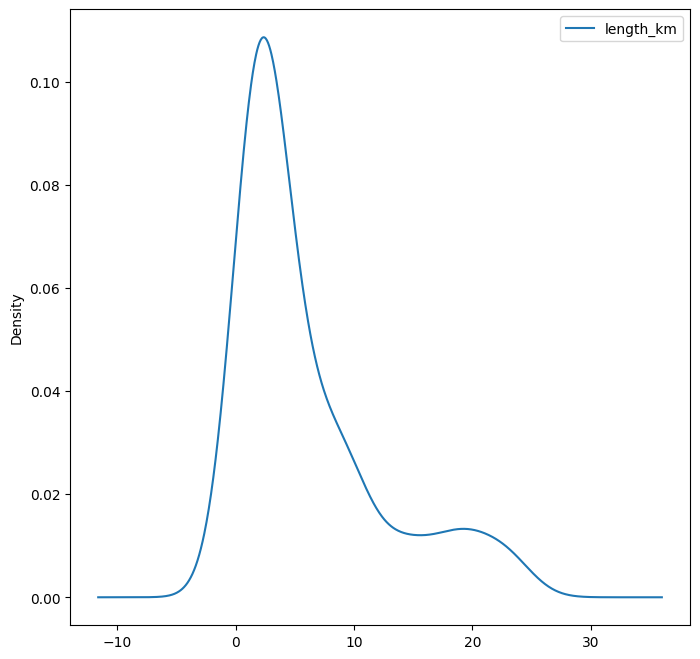

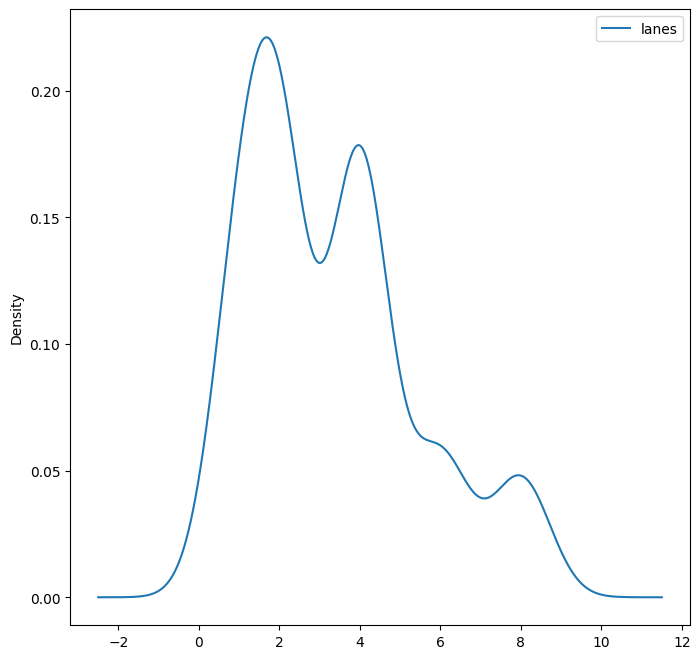

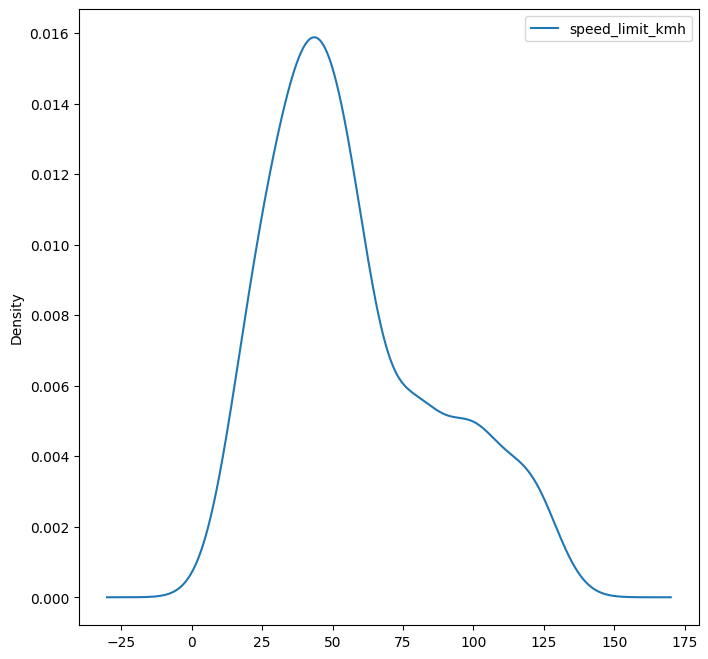

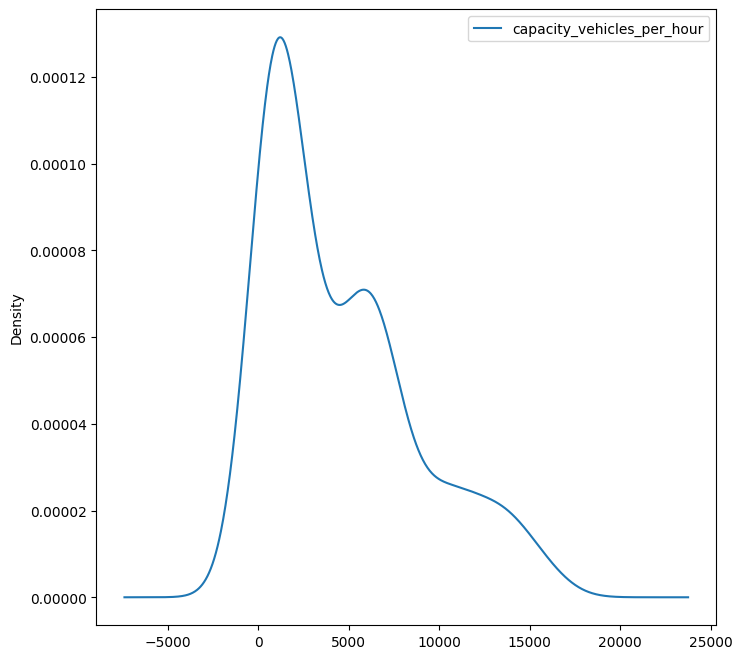

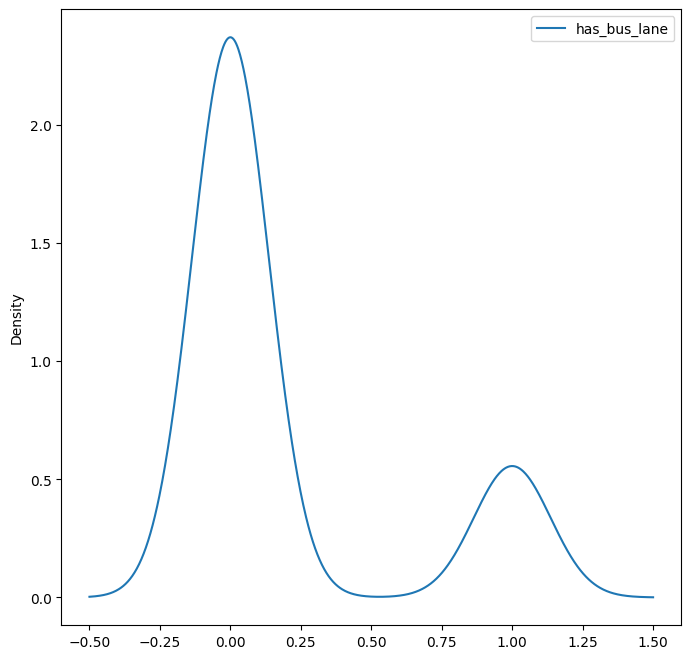

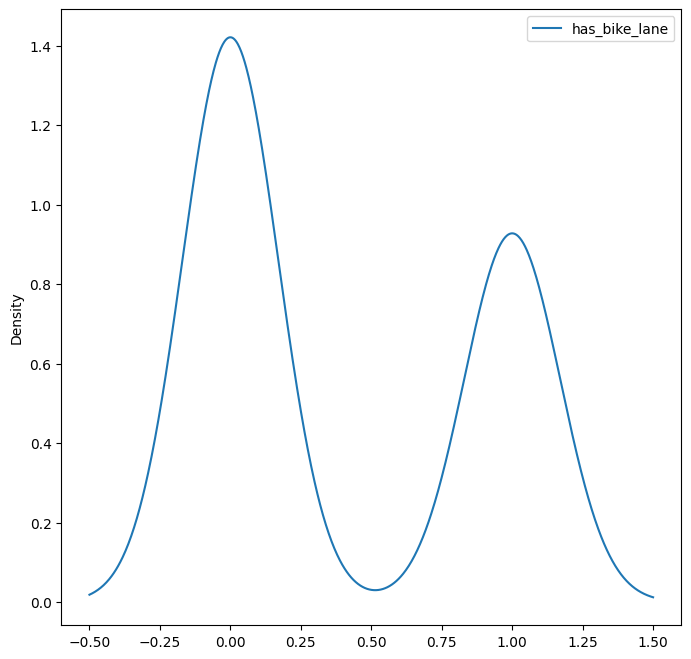

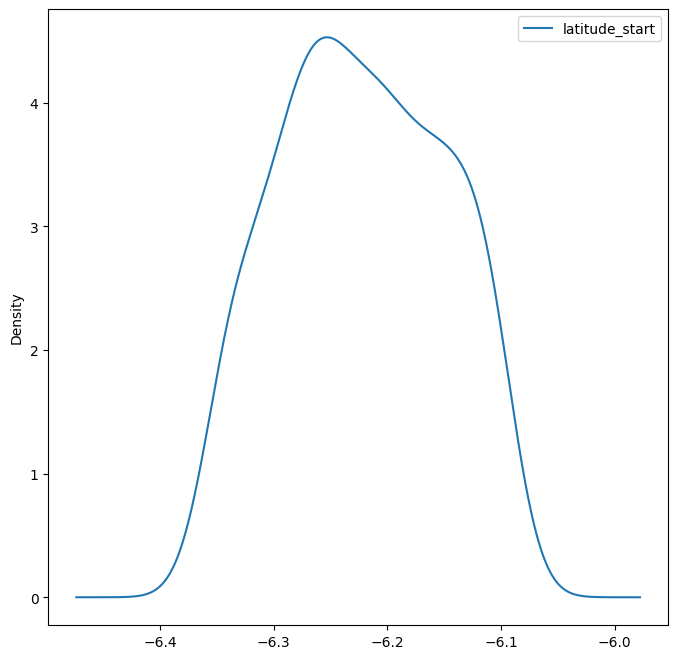

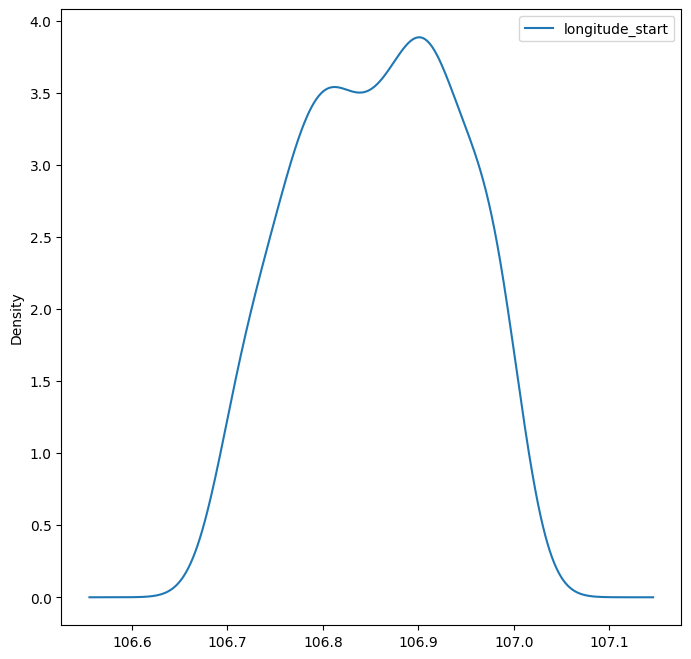

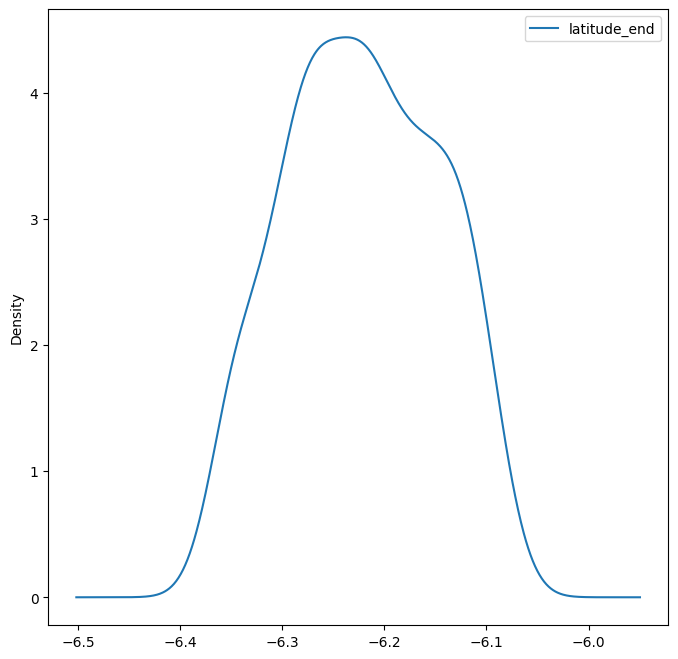

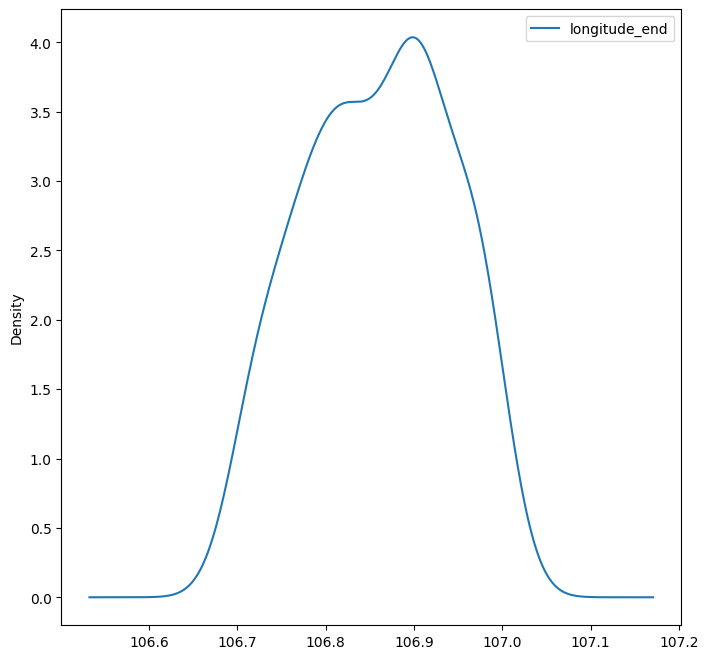

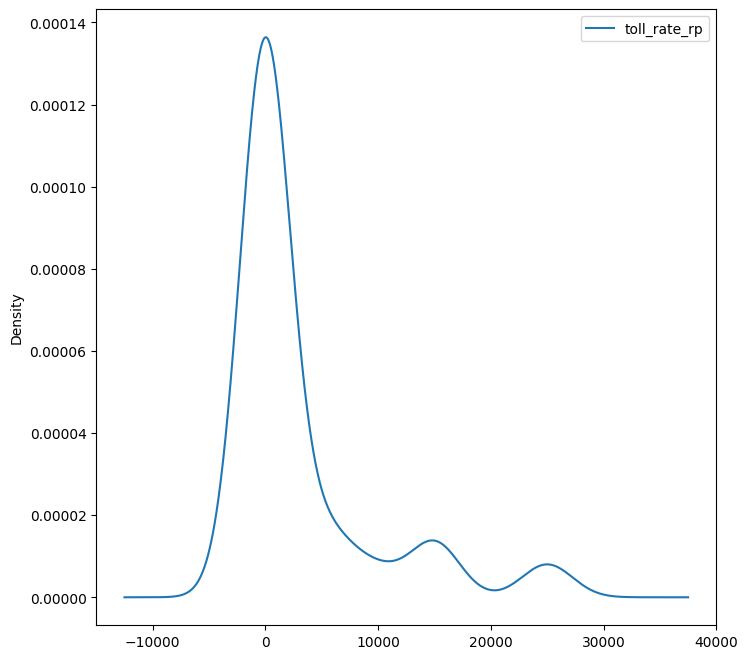

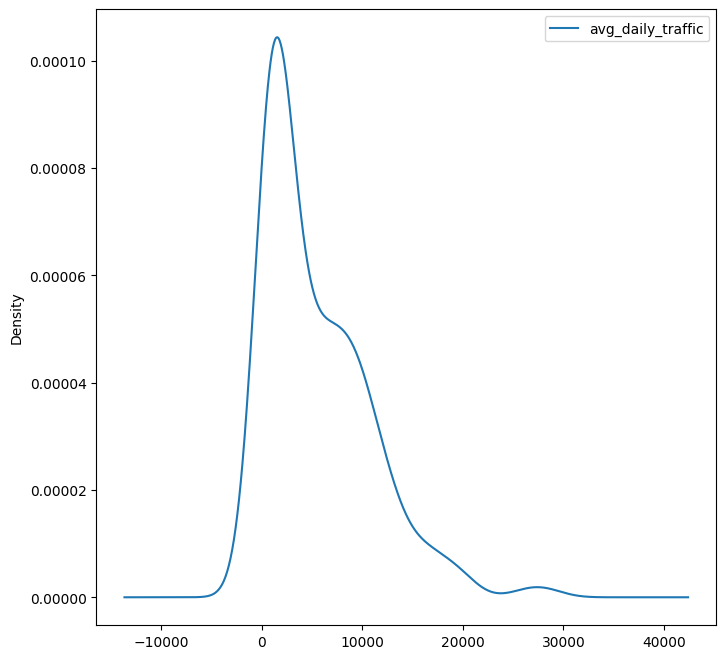

In [7]:
# custom function for printing all numeric columns plot
def plotkde(a):
    df.plot(y=[a], kind='kde',figsize=(8,8))
allnc = df.select_dtypes(include='number').columns
print(allnc)
for i in allnc:
    plotkde(i)

In [8]:
df.select_dtypes(include='object').columns

Index(['road_id', 'road_name', 'road_type', 'surface_condition',
       'last_maintenance_date', 'district'],
      dtype='object')

C:\Users\abhinavkuriya\anaconda3\Lib\site-packages\numpy\_core\_methods.py:193: RuntimeWarning: overflow encountered in multiply
  x = um.multiply(x, x, out=x)
C:\Users\abhinavkuriya\anaconda3\Lib\site-packages\numpy\_core\_methods.py:204: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(x, axis, dtype, out, keepdims=keepdims, where=where)


[[ 0.1689236   0.56328684  0.32386958 ...  0.95815104 -0.56193967
   1.10150388]
 [ 0.1689236   0.56328684  0.89446094 ... -1.06002133 -0.56193967
   0.66820961]
 [-0.76688671 -0.51661153 -0.45677182 ... -0.36771795 -0.56193967
  -0.98645446]
 ...
 [-1.43505968 -0.51661153 -1.72335191 ... -1.53104117 -0.56193967
  -0.74383383]
 [ 0.32993057  0.56328684 -0.03061885 ...  1.20486794 -0.56193967
   0.65463899]
 [ 1.56373211  1.71086714  0.89446094 ... -0.83795336  1.76127855
   1.49280176]]


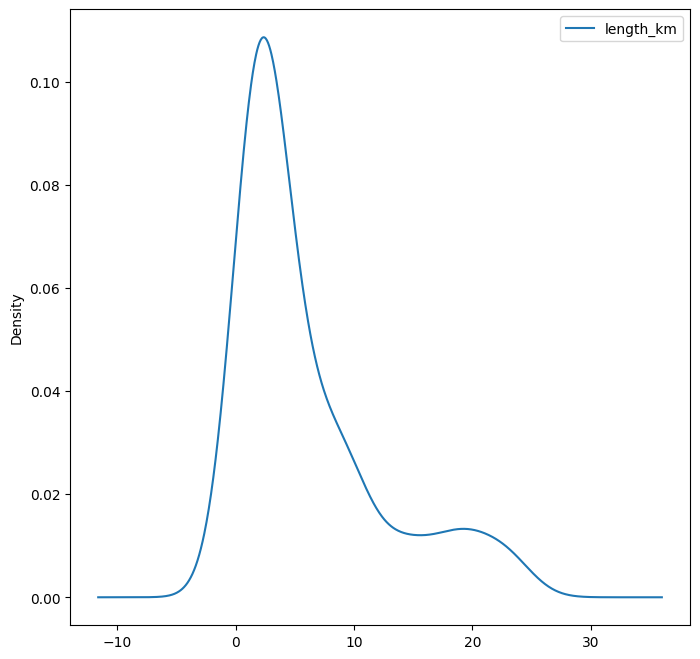

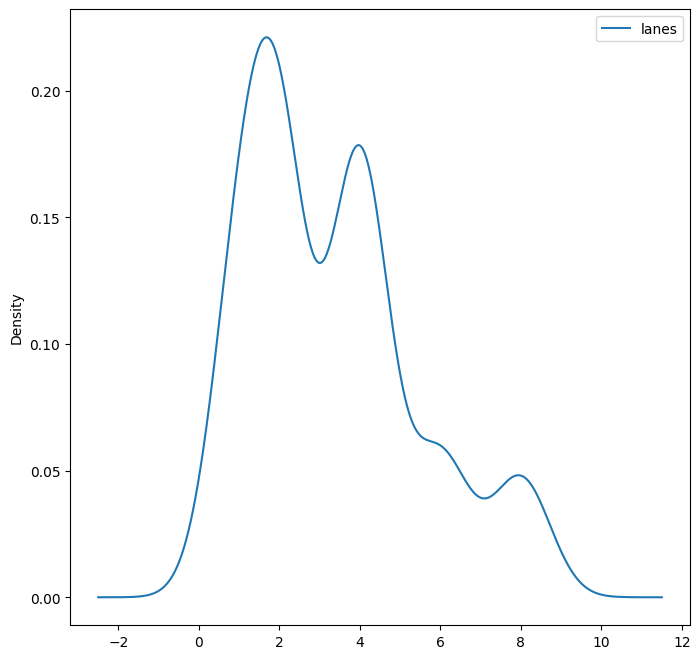

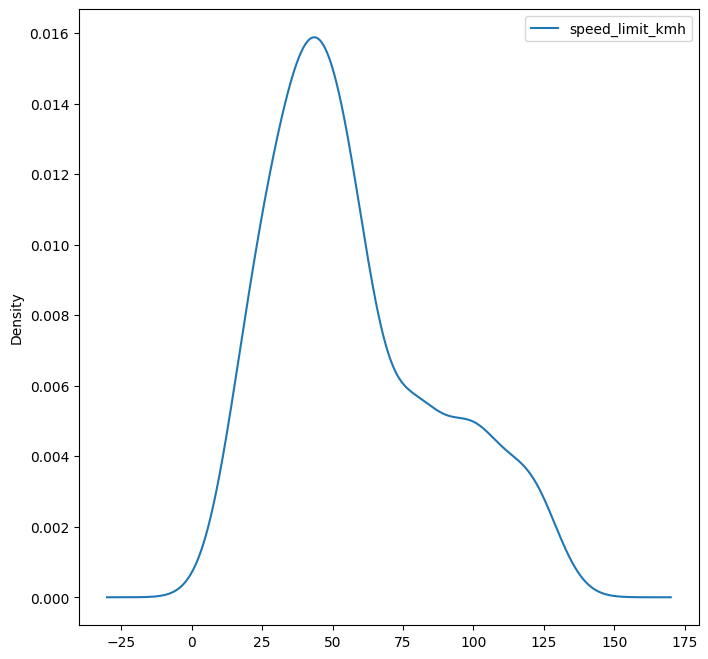

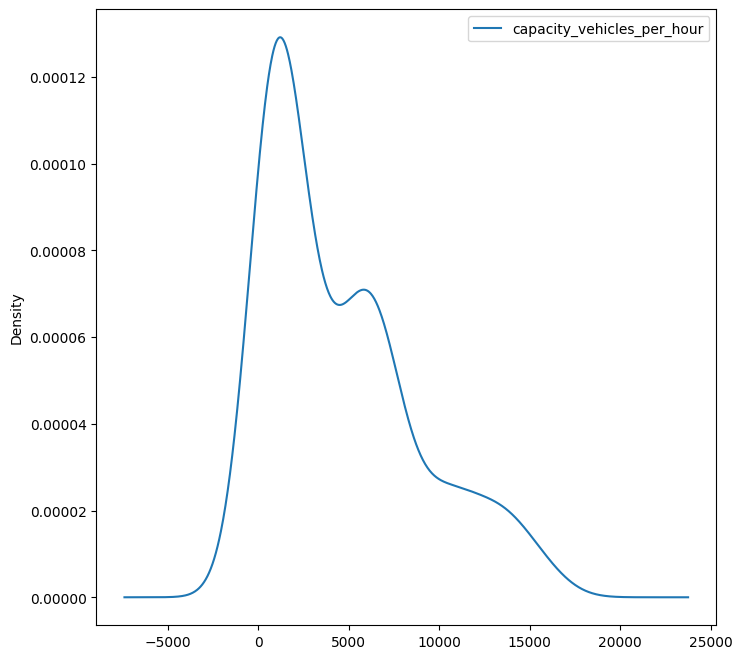

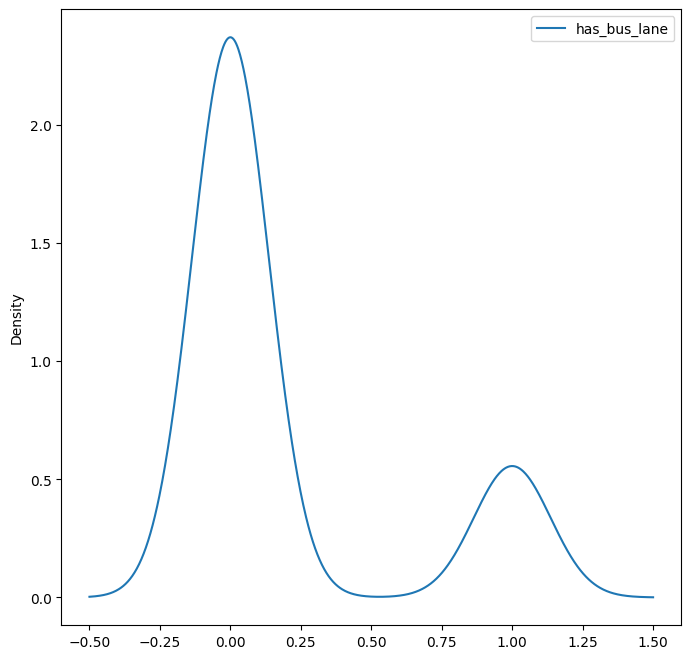

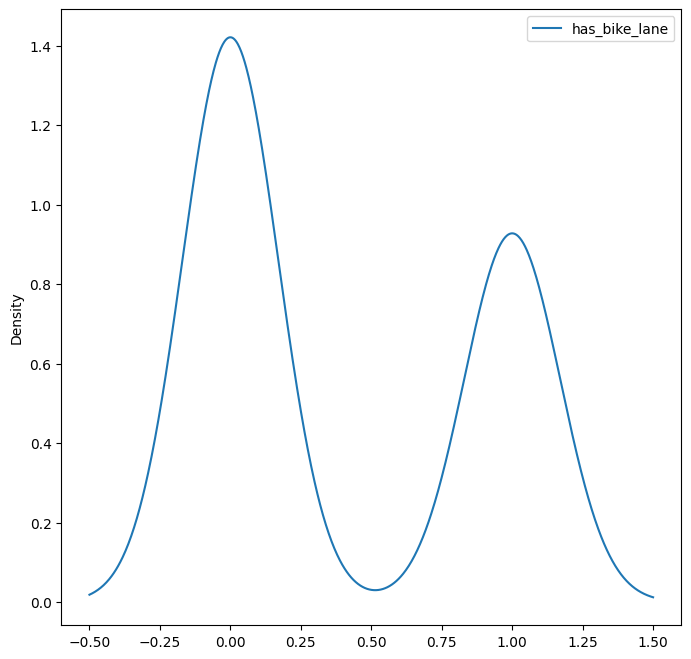

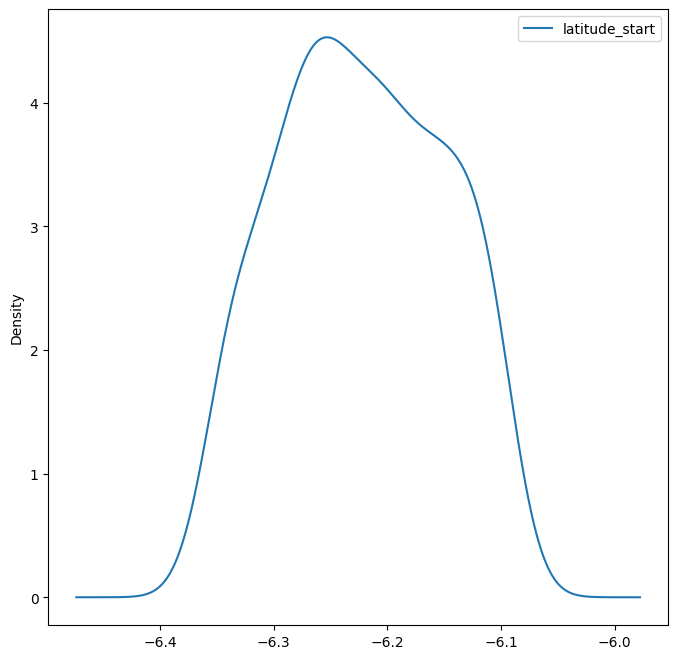

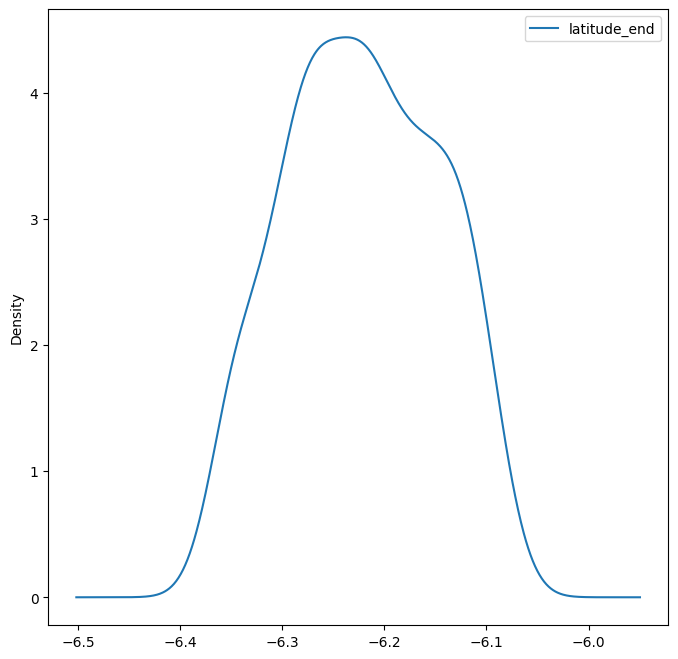

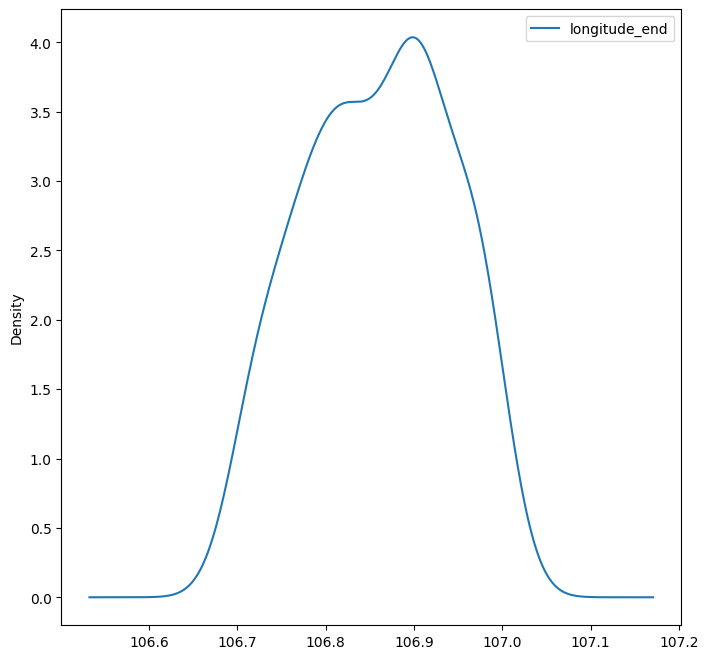

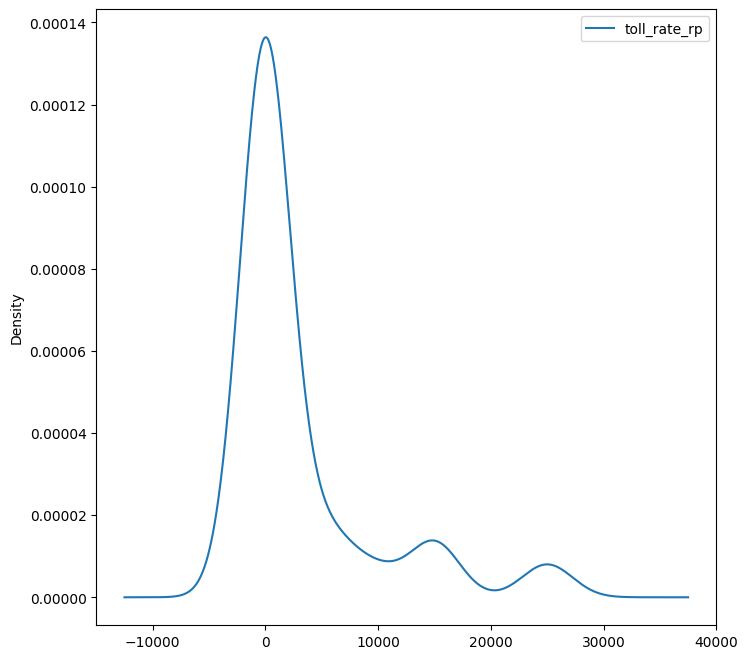

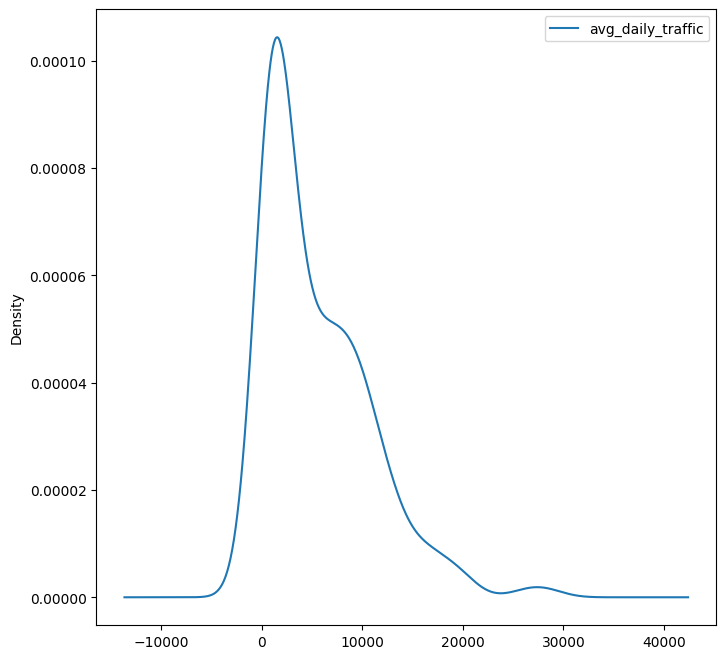

In [9]:
# after yeo-johnson

adf = df.drop(columns=['road_id', 'road_name', 'road_type', 'surface_condition',
                       'last_maintenance_date', 'district','longitude_start'])

tdf = adf

pt = PowerTransformer(method='yeo-johnson', standardize=True)
transformed = pt.fit_transform(tdf)

print(transformed)

transformed= pd.DataFrame(transformed, columns = adf.columns)
for i in transformed:
    plotkde(i)

In [10]:

for col in tdf.columns:
    try:
        pt = PowerTransformer(method='yeo-johnson')
        pt.fit_transform(tdf[[col]])
        print(f"{col}: OK")
    except Exception as e:
        print(f"{col}: ERROR -> {e}")

length_km: OK
lanes: OK
speed_limit_kmh: OK
capacity_vehicles_per_hour: OK
has_bus_lane: OK
has_bike_lane: OK
latitude_start: OK
latitude_end: OK
longitude_end: OK
toll_rate_rp: OK
avg_daily_traffic: OK


C:\Users\abhinavkuriya\anaconda3\Lib\site-packages\numpy\_core\_methods.py:193: RuntimeWarning: overflow encountered in multiply
  x = um.multiply(x, x, out=x)
C:\Users\abhinavkuriya\anaconda3\Lib\site-packages\numpy\_core\_methods.py:204: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(x, axis, dtype, out, keepdims=keepdims, where=where)


In [11]:
df.select_dtypes(include='number').columns

Index(['length_km', 'lanes', 'speed_limit_kmh', 'capacity_vehicles_per_hour',
       'has_bus_lane', 'has_bike_lane', 'latitude_start', 'longitude_start',
       'latitude_end', 'longitude_end', 'toll_rate_rp', 'avg_daily_traffic'],
      dtype='object')

In [12]:
# Yeo-Johnson completed its work and 
# now all the numerical columns are scaled and has their best possible lamda values
print('\n',pt.lambdas_)


 [0.06963675]


In [13]:
print(tdf.columns)

Index(['length_km', 'lanes', 'speed_limit_kmh', 'capacity_vehicles_per_hour',
       'has_bus_lane', 'has_bike_lane', 'latitude_start', 'latitude_end',
       'longitude_end', 'toll_rate_rp', 'avg_daily_traffic'],
      dtype='object')


In [14]:

X = df.drop(
    columns=[
        'avg_daily_traffic',
        'road_id',
        'road_name'
    ],
    errors='ignore'
)

y = df['avg_daily_traffic']


numeric_cols = X.select_dtypes(include='number').columns
categorical_cols = X.select_dtypes(include='object').columns


preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric_cols),
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_cols)
])


pipe = Pipeline([
    ('preprocess', preprocessor),
    ('model', LinearRegression())
])


X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)


pipe.fit(X_train, y_train)


print("Train R²:", pipe.score(X_train, y_train))
print("Test R²:", pipe.score(X_test, y_test))



Train R²: 0.9999999970937736
Test R²: 0.45703354418135933


C:\Users\abhinavkuriya\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [15]:
cv_scores = cross_val_score(
    pipe,
    X,
    y,
    cv=5,
    scoring='r2'
)

print("\nCV R² Scores:", cv_scores)
print("Mean CV R²:", cv_scores.mean())

C:\Users\abhinavkuriya\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
C:\Users\abhinavkuriya\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
C:\Users\abhinavkuriya\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
C:\Users\abhinavkuriya\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(



CV R² Scores: [0.71000395 0.63585897 0.65826182 0.59957162 0.49810422]
Mean CV R²: 0.6203601159921565


C:\Users\abhinavkuriya\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
